In [3]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from func_00 import *
from meer21cm.telescope import dish_beam_sigma
from matplotlib.colors import LogNorm
from astropy.cosmology import Planck18


In [4]:
def get_k_modes():
    mock = MockSimulation(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        tracer_bias_2=1.0,
        tracer_bias_1=1.0,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
        sigma_v_1=100,
        sigma_v_2=100,
    )
    mock.get_enclosing_box()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    return kperp_1, kpara_1, kmode_1, kvec_1
def bin_power_cy(
    power_3d,
    k_perp,
    k_para,
    kperpbins,
    kparabins,
    kweights=None,
):
    pcy_arr = bin_3d_to_cy(
        power_3d, k_perp, kperpbins, vectorize=True,
        weights=kweights,
    )
    pcy_arr = bin_3d_to_cy(
        np.nan_to_num(pcy_arr), np.abs(k_para), kparabins, vectorize=True,
        weights=(1-np.isnan(pcy_arr))[0].astype('float'),
    )
    return pcy_arr

def bin_power_1d(
    power_3d,
    k_mode,
    k1dbins,
    kweights,
    num_split=None,
):
    if num_split is None:
        p1d, keff, nmodes = bin_3d_to_1d(
            power_3d, k_mode, k1dbins, vectorize=True,weights=kweights,
        )
    else:
        p1d = []
        power_3d_arr = np.array_split(power_3d,num_split)
        for i in range(num_split):
            pdata1darr_i, keff, nmodes = bin_3d_to_1d(
                power_3d_arr[i], k_mode, k1dbins, vectorize=True,weights=kweights,
            )
            p1d.append(pdata1darr_i)
        p1d = np.concatenate(p1d)
    return p1d, keff, nmodes

In [5]:
kperp, kpara, kmode, kvec = get_k_modes()

In [7]:
k_xy_sel = (
    (np.abs(kvec[0])<0.016)[:,None,None] 
    * (np.abs(kvec[1])<0.016)[None,:,None]
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0

In [8]:
k_cy_sel = np.ones_like(kmode)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [9]:
data = np.load('/scratch3/users/ztchen/validation/00.npz')

In [11]:
data['pgmod3d_arr'].shape

(1, 27, 89, 260)

In [14]:
phimock_cy = bin_power_cy(
    data['pdata3d_arr'].mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pmodelcy_arr_1 = bin_power_cy(
    data['phimod3d_arr'],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]

pgmock_cy = bin_power_cy(
    data['pg3d_arr'].mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pgmodcy_arr_1 = bin_power_cy(
    data['pgmod3d_arr'],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]

pcrossmock_cy = bin_power_cy(
    data['pcross3d_arr'].mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pcrossmodcy_arr_1 = bin_power_cy(
    data['pcrossmod3d_arr'],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]

/users/ztchen/meer21cm/src/meer21cm/power.py:2054: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


In [15]:
pdata1darr = []
num_split = 20
pdata3darr = np.array_split(data['pdata3d_arr'],num_split)
for i in range(num_split):
    pdata1darr_i, keff, nmodes = bin_power_1d(
        pdata3darr[i],
        kmode,
        k1dbins,
        k_xy_sel,
    )
    pdata1darr.append(pdata1darr_i)
phimock1darr = np.concatenate(pdata1darr)
pmod1darr, _, _ = bin_power_1d(
    data['phimod3d_arr'][None],
    kmode,
    k1dbins,
    k_xy_sel,
)
phimod1darr=pmod1darr[0]

In [16]:
pdata1darr = []
num_split = 20
pdata3darr = np.array_split(data['pg3d_arr'],num_split)
for i in range(num_split):
    pdata1darr_i, keff, nmodes = bin_power_1d(
        pdata3darr[i],
        kmode,
        k1dbins,
        k_xy_sel,
    )
    pdata1darr.append(pdata1darr_i)
pgmock1darr = np.concatenate(pdata1darr)
pmod1darr, _, _ = bin_power_1d(
    data['pgmod3d_arr'][None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pgmod1darr=pmod1darr[0]

In [17]:
pdata1darr = []
num_split = 20
pdata3darr = np.array_split(data['pcross3d_arr'],num_split)
for i in range(num_split):
    pdata1darr_i, keff, nmodes = bin_power_1d(
        pdata3darr[i],
        kmode,
        k1dbins,
        k_xy_sel,
    )
    pdata1darr.append(pdata1darr_i)
pcrossmock1darr = np.concatenate(pdata1darr)
pmod1darr, _, _ = bin_power_1d(
    data['pcrossmod3d_arr'][None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pcrossmod1darr=pmod1darr[0]

In [19]:
keff = keff / Planck18.h

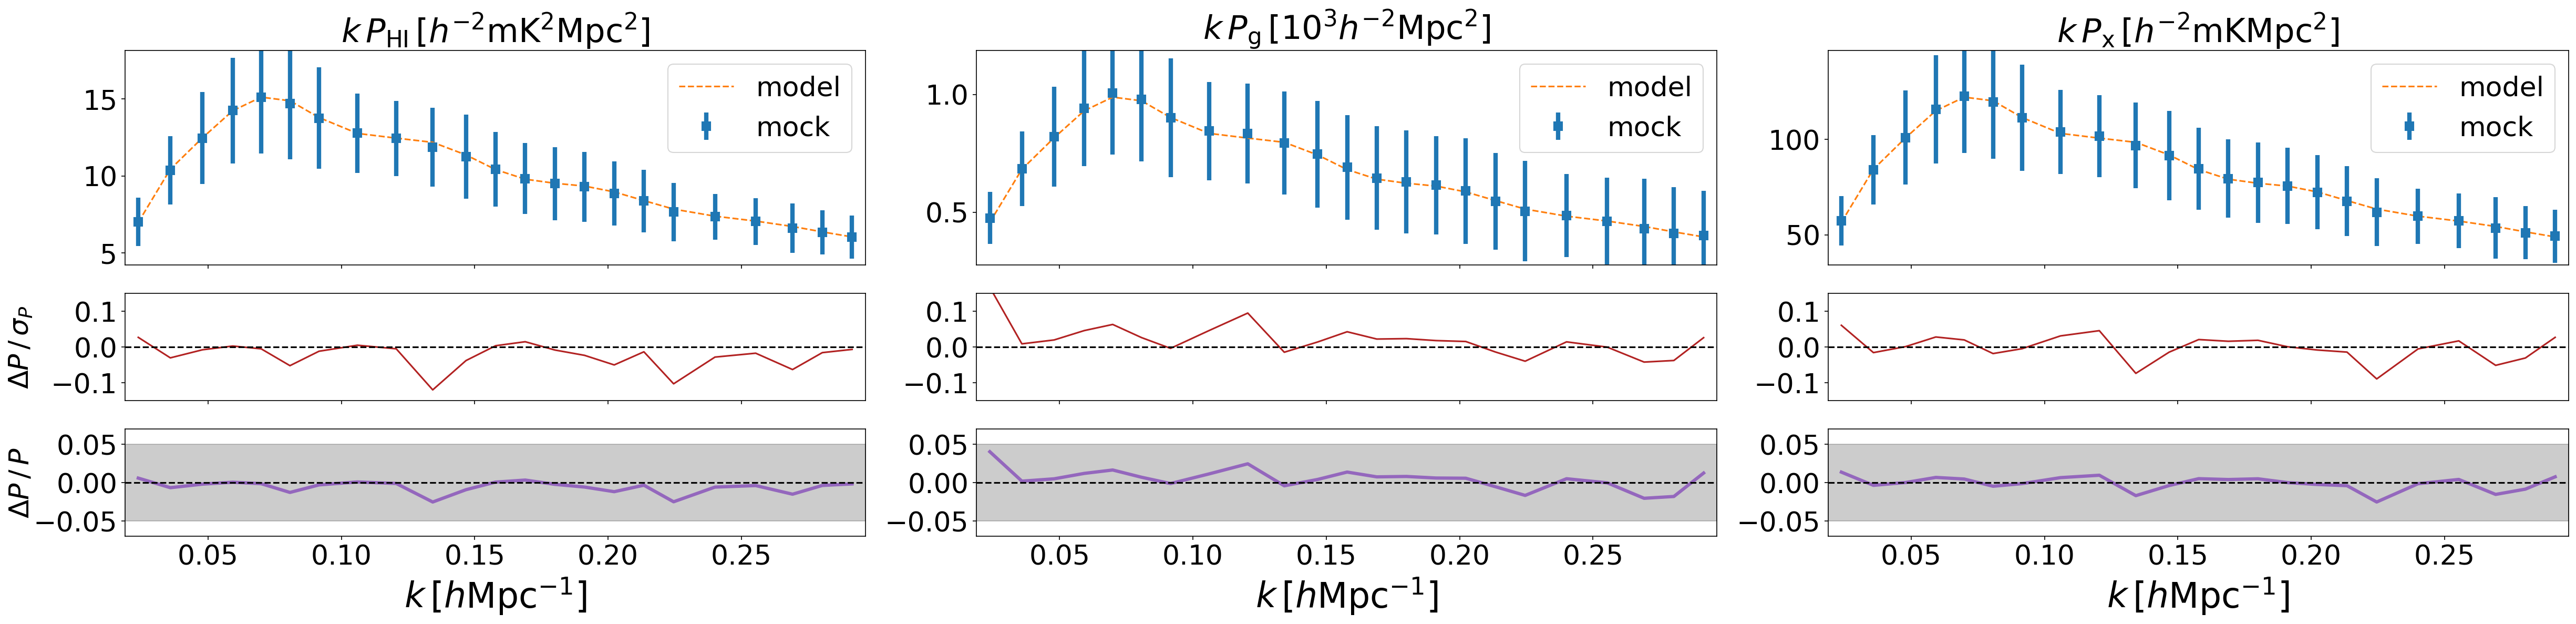

In [21]:
plt.rcParams['font.size'] = 25
fig,axes=plt.subplots(
    3,3,figsize=(40,8),sharex=True,
    height_ratios=[2,1,1],dpi=150,
    gridspec_kw={'wspace':0.15},
)
ratio_min,ratio_max = (-0.15,0.15)
pmockarr = [phimock1darr*1e6,pgmock1darr/1e3,pcrossmock1darr*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = [phimod1darr*1e6,pgmod1darr/1e3,pcrossmod1darr*1e3]
pmodelarr = np.array(pmodelarr) * Planck18.h**3
#titlearr = [r'HI power',r'Galaxy power',r'Cross power']
titlearr= [
    r'$k\,P_{\rm HI}\,[ h^{-2} {\rm mK^2 Mpc^2}]$',
    r'$k\,P_{\rm g}\,[ 10^3 h^{-2}{\rm Mpc^2}]$',
    r'$k\,P_{\rm x}\,[h^{-2} {\rm mKMpc^2}]$',
]
for i in range(3):
    pdatad = pmockarr[i]
    pmodd = pmodelarr[i]
    axes[0,i].errorbar(
        keff,
        pdatad.mean(axis=0) * keff,
        yerr=pdatad.std(axis=0) * keff,
        label="mock",
        ls='None',
        elinewidth=4,
        marker='s',
        markersize=8,
    )
    axes[0,i].plot(keff, pmodd * keff, label="model", ls="--")
    axes[0,i].set_ylim((pmodd * keff).min() * 0.7, (pmodd * keff).max() * 1.2)
    axes[0,i].legend()
    #axes[0,i].set_ylabel(ylabelarr[i],labelpad=30)
    axes[0,i].set_title(titlearr[i])
    axes[1,i].plot(
        keff,
        (pdatad.mean(axis=0)- pmodd) / (pdatad.std(axis=0)),
        #yerr=(pdatad.std(axis=0)) / (pmodd) / np.sqrt(len(pdatad)),
        color='firebrick',
    )
    axes[1,i].axhline(0, color="black", ls="--")
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.05, 0.05, color="black", alpha=0.2,
    #)
    #axes[1,i].fill_between(
    #    np.linspace(keff.min()-0.005,keff.max()+0.005,100), 
    #    -0.02, 0.02, color="black", alpha=0.2,
    #)
    axes[1,i].set_xlim(keff.min()-0.005,keff.max()+0.005)
    axes[1,i].set_ylim(ratio_min,ratio_max)
    if i == 0:
        axes[1,i].set_ylabel(r'$\Delta P \, / \,\sigma_P$',labelpad=15)

    axes[2,i].plot(
        keff,
        (pdatad.mean(axis=0)) / (pmodd) - 1,
        lw=3,
        color='C4',
        #yerr=(pdatad.std(axis=0)) / (pmodd),
    )
    axes[2,i].axhline(0, color="black", ls="--")
    axes[2,i].fill_between(
        np.linspace(keff.min() - 0.005, keff.max() + 0.005, 100),
        -0.05,
        0.05,
        color="black",
        alpha=0.2,
    )
    axes[2,i].set_xlim(keff.min() - 0.005, keff.max() + 0.005)
    axes[2,i].set_ylim(-0.07, 0.07)
    axes[2,i].set_xlabel(r'$k\,[h{\rm Mpc^{-1}}]$', fontsize=32)
    if i == 0:
        axes[2,i].set_ylabel(r'$\Delta P \, / \,P$',labelpad=-1)
plt.savefig('plots/mock_validation_1d.pdf',dpi=150, bbox_inches = "tight")

In [22]:
import matplotlib.ticker as tck

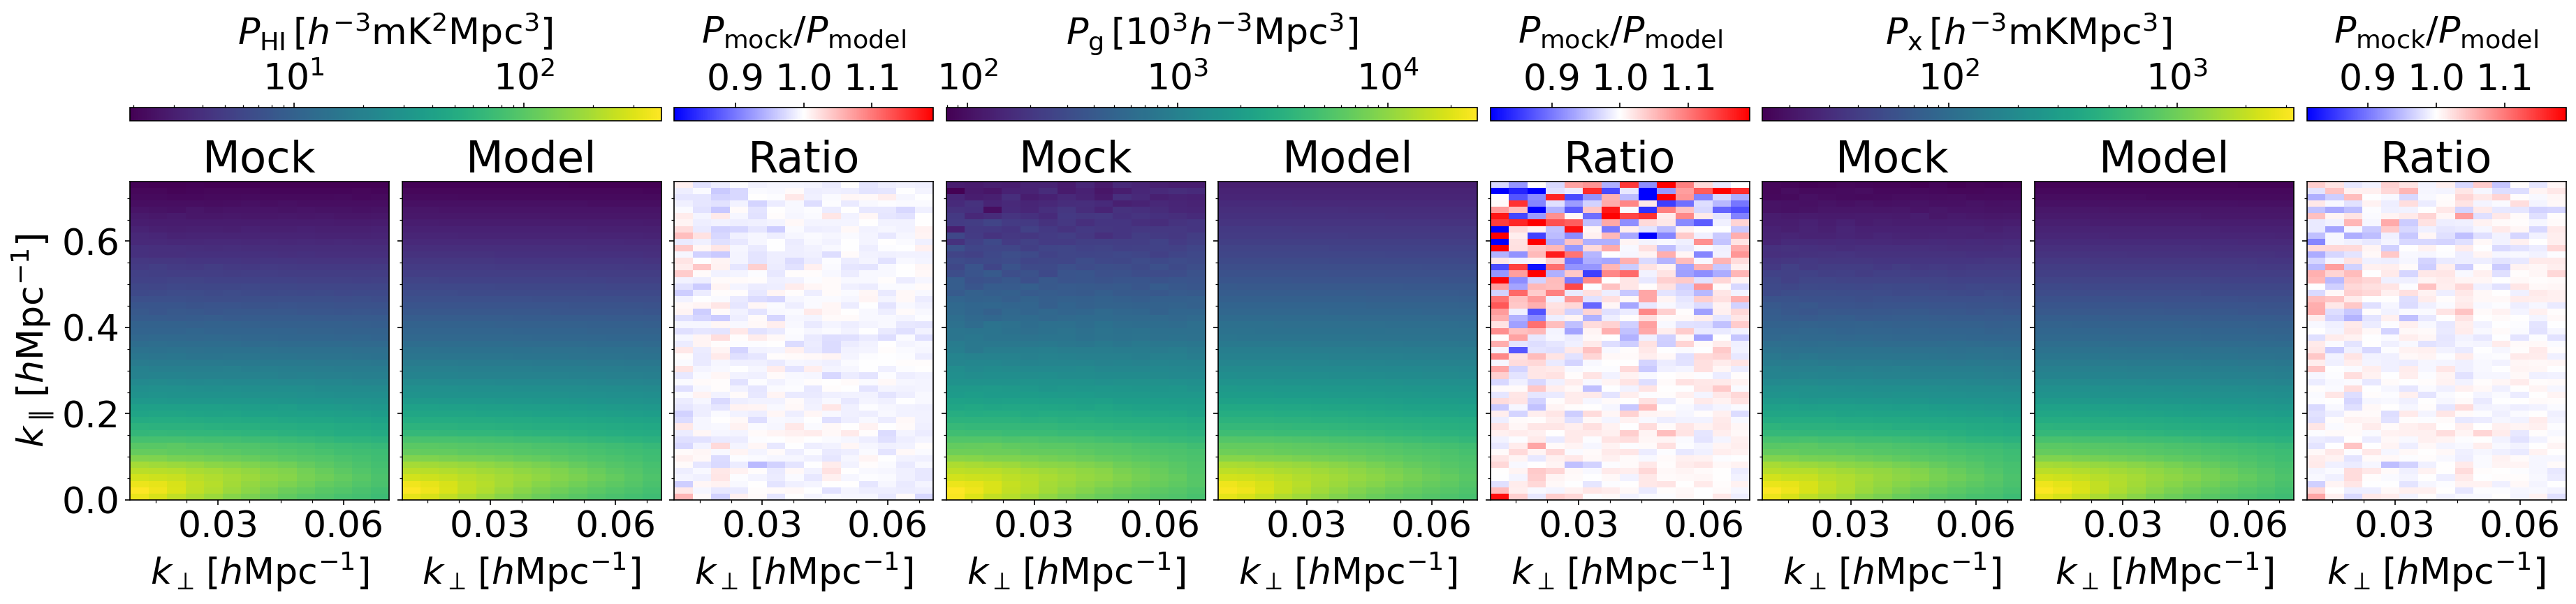

In [26]:
plt.rcParams['font.size'] = 25
fig, axes = plt.subplots(1, 9,figsize=(30,5),gridspec_kw={'wspace':0.05},dpi=150)
pmockarr = [phimock_cy*1e6,pgmock_cy,pcrossmock_cy*1e3]
pmodelarr = [pmodelcy_arr_1*1e6,pgmodcy_arr_1,pcrossmodcy_arr_1*1e3]
pmockarr = np.array(pmockarr) * Planck18.h**3
pmodelarr = np.array(pmodelarr) * Planck18.h**3
ylabelarr= [
    r'$P_{\rm HI}\,[ h^{-3} {\rm mK^2 Mpc^3}]$',
    r'$P_{\rm g}\,[ 10^3 h^{-3}{\rm Mpc^3}]$',
    r'$P_{\rm x}\,[h^{-3} {\rm mK Mpc^3}]$',
]
for i in range(3):
    xbins = kperpbins / Planck18.h
    ybins = kparabins / Planck18.h
    pdatacy = pmockarr[i]
    pmodcy = pmodelarr[i]
    arr = np.array([
        (pdatacy.mean(axis=0).T),
        (pmodcy.T),
    ])
    vmin = np.nanmin(arr)
    vmax = np.nanmax(arr)
    axes[0+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.mean(axis=0).T),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    if i>0:
        axes[0+i*3].set_yticklabels([])
    else:
        axes[0+i*3].set_ylabel(r'$k_\parallel\,[h{\rm Mpc^{-1}}]$')
    axes[0+i*3].set_title(r'Mock')
    
    im = axes[1+i*3].pcolormesh(
        xbins,
        ybins,
        (pmodcy.T),
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    axes[1+i*3].set_yticklabels([])
    axes[1+i*3].set_title(r'Model')
    
    cbar = plt.colorbar(im,ax=axes[0+i*3:2+i*3],location="top",fraction=0.06,pad=0.15,aspect=40)
    cbar.set_label(ylabelarr[i],labelpad=12)
    im = axes[2+i*3].pcolormesh(
        xbins,
        ybins,
        (pdatacy.mean(axis=0).T) / (pmodcy.T),
        #vmin=vmin_ratio,
        #vmax=vmax_ratio,
        vmin=0.81,
        vmax=1.19,
        cmap="bwr",
    )
    axes[2+i*3].set_yticklabels([])
    axes[2+i*3].set_title('Ratio')
    
    cbar = plt.colorbar(im,ax=axes[2+i*3],location="top",fraction=0.06,pad=0.15)
    cbar.set_label(r'$P_{\rm mock} / P_{\rm model}$',labelpad=14)
    #ml = MultipleLocator(5)
    for j in range(3):
        axes[j+i*3].set_xticks([0.03,0.06])
        axes[j+i*3].yaxis.set_minor_locator(tck.AutoMinorLocator())
        axes[j+i*3].xaxis.set_minor_locator(tck.AutoMinorLocator())
        #axes[j+i*3].set_xticks(np.linspace(0.01,0.07,7))
        #xticklabels = ['',] * 7
        #xticklabels[2] = '0.03'
        #xticklabels[5] = '0.06'
        
        #axes[j+i*3].set_xticklabels(xticklabels)
        #axes[j+i*3].xaxis.set_minor_locator(ml)
        #axes[j+i*3].yaxis.set_minor_locator(ml)
        
for ax in axes:
    ax.set_xlabel(r'$k_\perp\,[h{\rm Mpc^{-1}}]$')
plt.savefig('plots/mock_validation_cy.pdf',dpi=150, bbox_inches = "tight")